# Домашнє завдання



Ну що, вже налаштувалися на виконання нового завдання? Тодi полетiли!

Сьогодні ви застосуєте перетворення Фур'є для побудови спектрограми звукових сигналів, що є підготовчим етапом для класифікації. Ви використаєте набір даних ESC-50 для визначення спектрограм та подальшої кластеризації спостережень з метою виявити звуки схожого походження.

Це допоможе закрiпити наступні навички:  

- обчислення перетворення Фур'є;
- застосування швидкого перетворення Фур'є при обробці звуку з метою генерації ознак, які далі можуть використовуватись для кластеризації чи класифікації.

## Завдання (крок за кроком)

Для цієї задачі необхідно буде завантажити набір даних ESC-50, як це було зроблено в конспекті.

 Для виконання завдання необхідно виконати такі кроки:

1. Для зменшення обсягу даних зробити вибірку звуків із мітками 'dog' та 'chirping_birds'.  

2. За допомогою наведеної в конспекті функції spectrogram згенерувати матрицю спектрограми.

3. Використати функцію pooling для узагальнення та зменшення розміру спектрограми.

4. За допомогою методу flaten() перетворити матрицю спектрограми у вектор.

5. Використати функцію SpectralClustering бібліотеки sklearn для кластеризації отриманих даних (аналогічно до ДЗ теми №1).

6. Проаналізувати отримані кластери. Чи потрапили в різні кластери звуки різного походження?

7. Зробити висновок про значення застосування перетворення Фур'є для вилучення ознак даних.


## Пiдказки

Для виконання завдання використовуй функції numpy та алгоритми з конспекту до цієї теми.

## Формат здачі

1. Завантажте блокнот Google Colab у форматі IPYNB на свій комп’ютер та прикріпіть його у LMS.

2. Прикріпіть посилання на ваш Colab у LMS, відправте на перевірку.

## Критерії прийняття завдання

- Усі вказані етапи виконані та проведені обчислювальні експерименти з різними ступенями стискання.
- До Colab додані висновки.

## Формат оцінювання
Залiк / Незалiк

## Приклад

Функції, необхідні для виконання ДЗ. Наводяться в конспекті.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score
import librosa
import librosa.display

In [ ]:
def spectrogram(samples, sample_rate, stride_ms = 10.0,
                          window_ms = 20.0, max_freq = None, eps = 1e-14):

    stride_size = int(0.001 * sample_rate * stride_ms)
    window_size = int(0.001 * sample_rate * window_ms)

    # Extract strided windows
    truncate_size = (len(samples) - window_size) % stride_size
    samples = samples[:len(samples) - truncate_size]
    nshape = (window_size, (len(samples) - window_size) // stride_size + 1)
    nstrides = (samples.strides[0], samples.strides[0] * stride_size)
    windows = np.lib.stride_tricks.as_strided(samples,
                                          shape = nshape, strides = nstrides)

    assert np.all(windows[:, 1] == samples[stride_size:(stride_size + window_size)])

    # Window weighting, squared Fast Fourier Transform (fft), scaling
    weighting = np.hanning(window_size)[:, None]

    fft = np.fft.rfft(windows * weighting, axis=0)
    fft = np.absolute(fft)
    fft = fft**2

    scale = np.sum(weighting**2) * sample_rate
    fft[1:-1, :] *= (2.0 / scale)
    fft[(0, -1), :] /= scale

    # Prepare fft frequency list
    freqs = float(sample_rate) / window_size * np.arange(fft.shape[0])

    # Compute spectrogram feature
    # ind = np.where(freqs <= max_freq)[0][-1] + 1
    specgram = np.log(fft[:, :] + eps)
    return specgram

In [ ]:
def pooling_audio(mat,ksize,method='max',pad=False):
    '''Non-overlapping pooling on 2D or 3D data.

    <mat>: ndarray, input array to pool.
    <ksize>: tuple of 2, kernel size in (ky, kx).
    <method>: str, 'max for max-pooling,
                   'mean' for mean-pooling.
    <pad>: bool, pad <mat> or not. If no pad, output has size
           n//f, n being <mat> size, f being kernel size.
           if pad, output has size ceil(n/f).

    Return <result>: pooled matrix.
    '''

    m, n = mat.shape[:2]
    ky,kx=ksize

    _ceil=lambda x,y: int(np.ceil(x/float(y)))

    if pad:
        ny=_ceil(m,ky)
        nx=_ceil(n,kx)
        size=(ny*ky, nx*kx)+mat.shape[2:]
        mat_pad=np.full(size,np.nan)
        mat_pad[:m,:n,...]=mat
    else:
        ny=m//ky
        nx=n//kx
        mat_pad=mat[:ny*ky, :nx*kx, ...]

    new_shape=(ny,ky,nx,kx)+mat.shape[2:]

    if method=='max':
        result=np.nanmax(mat_pad.reshape(new_shape),axis=(1,3))
    else:
        result=np.nanmean(mat_pad.reshape(new_shape),axis=(1,3))

    return result


Генерація синтетичних сигналів

In [ ]:
def generate_signal(freqs, sr=16000, duration=2.0):
    t = np.linspace(0, duration, int(sr*duration), endpoint=False)
    signal = np.zeros_like(t)
    for f in freqs:
        signal += np.sin(2 * np.pi * f * t)
    return signal

sr = 16000
n_signals = 30

# Сигнали з низькими частотами
low_freq_signals = [generate_signal(np.random.choice([100, 150, 200], 2), sr) for _ in range(n_signals)]
# Сигнали з високими частотами
high_freq_signals = [generate_signal(np.random.choice([2000, 3000, 4000], 2), sr) for _ in range(n_signals)]


Побудова спектрограм і згортка

In [ ]:
X = []
y = []

for sig in low_freq_signals:
    spec = spectrogram(sig, sr)
    pooled = pooling_audio(spec, (5, 5))
    X.append(pooled.flatten())
    y.append(0)

for sig in high_freq_signals:
    spec = spectrogram(sig, sr)
    pooled = pooling_audio(spec, (5, 5))
    X.append(pooled.flatten())
    y.append(1)

X = np.array(X)
y = np.array(y)


Кластеризація та аналіз якості

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Adjusted Rand Index: 1.00
Високочастотні спектрограми


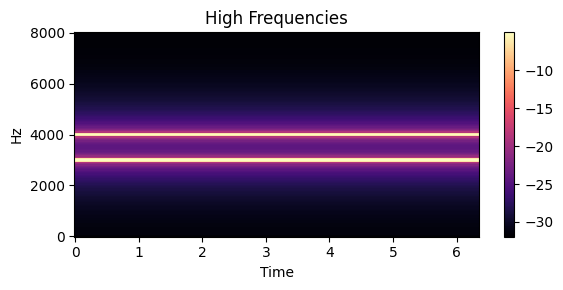

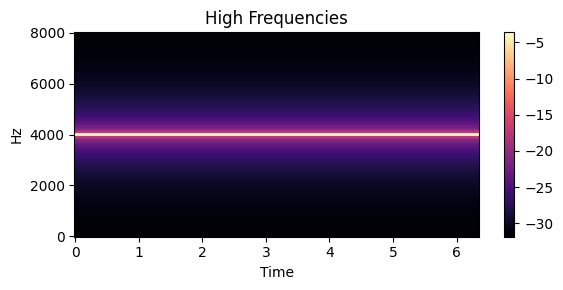

Низькочастотні спектрограми


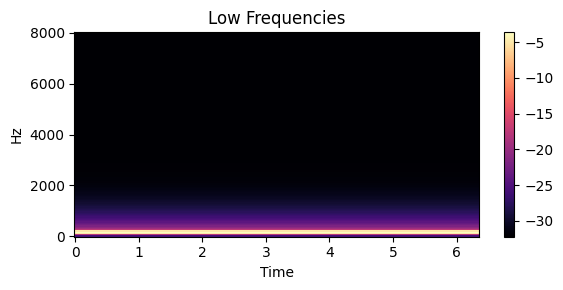

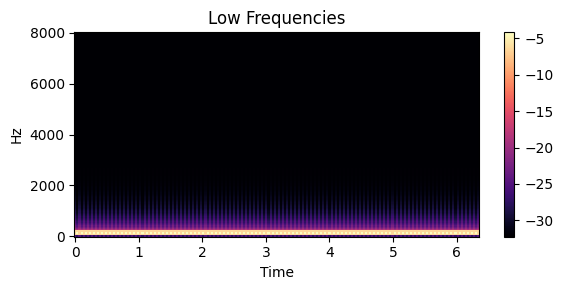

In [ ]:
clustering = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=0)
cluster_labels = clustering.fit_predict(X)

ari = adjusted_rand_score(y, cluster_labels)
print(f"Adjusted Rand Index: {ari:.2f}")

def show_spec(sig, sr, title):
    spec = spectrogram(sig, sr)
    plt.figure(figsize=(6, 3))
    librosa.display.specshow(spec, sr=sr, x_axis='time', y_axis='linear')
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

print("Високочастотні спектрограми")
for i in range(2):
    show_spec(high_freq_signals[i], sr, "High Frequencies")

print("Низькочастотні спектрограми")
for i in range(2):
    show_spec(low_freq_signals[i], sr, "Low Frequencies")


---
# Розв'язання домашнього завдання

Нижче розв'язання на реальних даних ESC-50: вибірка звуків категорій `dog` і `chirping_birds`, побудова спектрограм за допомогою функції `spectrogram` з конспекту, узагальнення через `pooling_audio` з експериментами над різними ступенями стискання, кластеризація `SpectralClustering` та аналіз результатів.

**Примітка щодо завантаження даних.** Повний архів ESC-50 важить ~600 МБ. Щоб не тягнути весь набір, ми завантажуємо лише файл метаданих `meta/esc50.csv` (у ньому вказано категорію кожного запису) і за ним вибірково довантажуємо із GitHub тільки ті 80 аудіофайлів, які належать до категорій `dog` та `chirping_birds` (по 40 на категорію).

### Крок 1. Вибірка звуків категорій `dog` та `chirping_birds` з ESC-50

In [13]:
import os
import csv
import urllib.request

ESC50_META_URL = "https://raw.githubusercontent.com/karoldvl/ESC-50/master/meta/esc50.csv"
ESC50_AUDIO_BASE = "https://raw.githubusercontent.com/karoldvl/ESC-50/master/audio/"
TARGET_CATEGORIES = ["dog", "chirping_birds"]
AUDIO_DIR = "esc50_audio"
META_PATH = "esc50.csv"

os.makedirs(AUDIO_DIR, exist_ok=True)

# Завантажуємо лише файл метаданих (маленький csv), а не весь архів ESC-50 (~600 МБ):
# так ми зможемо вибірково завантажити тільки потрібні нам аудіозаписи.
if not os.path.exists(META_PATH):
    urllib.request.urlretrieve(ESC50_META_URL, META_PATH)

with open(META_PATH, encoding="utf-8") as f:
    meta_rows = list(csv.DictReader(f))

subset_meta = [r for r in meta_rows if r["category"] in TARGET_CATEGORIES]
category_map = {r["filename"]: r["category"] for r in subset_meta}
print(f"У метаданих ESC-50 знайдено {len(subset_meta)} записів для категорій {TARGET_CATEGORIES}")

for row in subset_meta:
    fn = row["filename"]
    out_path = os.path.join(AUDIO_DIR, fn)
    if not os.path.exists(out_path):
        urllib.request.urlretrieve(ESC50_AUDIO_BASE + fn, out_path)

file_list = sorted(os.listdir(AUDIO_DIR))
print("Завантажено аудіофайлів:", len(file_list))


def load_audio(path):
    """Зчитує wav-файл як моно-сигнал float32 у діапазоні [-1, 1] + частоту дискретизації.

    Використовує librosa, якщо вона доступна в середовищі (як у конспекті),
    інакше — scipy.io.wavfile (щоб код працював і без встановленої librosa).
    """
    try:
        import librosa
        samples, sr = librosa.load(path, sr=None, mono=True)
        return samples.astype(np.float32), sr
    except ImportError:
        from scipy.io import wavfile
        sr, samples = wavfile.read(path)
        if samples.ndim > 1:
            samples = samples.mean(axis=1)
        samples = samples.astype(np.float32) / 32768.0
        return samples, sr

У метаданих ESC-50 знайдено 80 записів для категорій ['dog', 'chirping_birds']
Завантажено аудіофайлів: 80


### Крок 2. Побудова спектрограм (перетворення Фур'є)

Для кожного із 80 завантажених аудіофайлів застосовуємо функцію `spectrogram` з конспекту (короткочасне перетворення Фур'є, STFT) і зберігаємо матрицю разом зі справжньою міткою категорії.

In [14]:
labels_map = {"dog": 0, "chirping_birds": 1}

spectrograms = {}
for fn in file_list:
    samples, sr = load_audio(os.path.join(AUDIO_DIR, fn))
    spectrograms[fn] = (spectrogram(samples, sr), labels_map[category_map[fn]])

example_shape = next(iter(spectrograms.values()))[0].shape
print("Кількість спектрограм:", len(spectrograms))
print("Розмір однієї спектрограми (частоти x час):", example_shape)
print("Розмір спектрограми у вигляді вектора (без pooling):", example_shape[0] * example_shape[1])

Кількість спектрограм: 80
Розмір однієї спектрограми (частоти x час): (442, 499)
Розмір спектрограми у вигляді вектора (без pooling): 220558


### Крок 3. Pooling, flatten та експерименти з різними ступенями стискання

Функцією `pooling_audio` узагальнюємо (стискаємо) кожну спектрограму, а потім `.flatten()` перетворює її на вектор ознак. Щоб виконати вимогу "провести обчислювальні експерименти з різними ступенями стискання", переберемо кілька розмірів ядра pooling (`2×2` … `40×40`) та обидва методи (`max` і `mean`), і для кожної комбінації порахуємо якість кластеризації (`Adjusted Rand Index`, ARI) відносно справжніх категорій.

In [15]:
pool_grid = [(2, 2), (3, 3), (5, 5), (10, 10), (20, 20), (40, 40)]
sweep_rows = []
for method in ["max", "mean"]:
    for ksize in pool_grid:
        X_tmp, y_tmp = [], []
        for fn, (spec, label) in spectrograms.items():
            pooled = pooling_audio(spec, ksize, method=method)
            X_tmp.append(pooled.flatten())
            y_tmp.append(label)
        X_tmp = np.array(X_tmp)
        y_tmp = np.array(y_tmp)
        clustering = SpectralClustering(n_clusters=2, affinity="nearest_neighbors", random_state=0)
        cl_labels = clustering.fit_predict(X_tmp)
        ari = adjusted_rand_score(y_tmp, cl_labels)
        sweep_rows.append({
            "pooling": method,
            "kernel": f"{ksize[0]}x{ksize[1]}",
            "dim_after_pooling": X_tmp.shape[1],
            "compression_x": round(example_shape[0] * example_shape[1] / X_tmp.shape[1], 1),
            "ARI": round(ari, 3),
        })

sweep_df = pd.DataFrame(sweep_rows)
print("Якість кластеризації (ARI) для різних ступенів стискання (pooling):")
print(sweep_df.to_string(index=False))

Якість кластеризації (ARI) для різних ступенів стискання (pooling):
pooling kernel  dim_after_pooling  compression_x   ARI
    max    2x2              55029            4.0 0.084
    max    3x3              24402            9.0 0.383
    max    5x5               8712           25.3 0.352
    max  10x10               2156          102.3 0.322
    max  20x20                528          417.7 0.240
    max  40x40                132         1670.9 0.294
   mean    2x2              55029            4.0 0.415
   mean    3x3              24402            9.0 0.383
   mean    5x5               8712           25.3 0.415
   mean  10x10               2156          102.3 0.415
   mean  20x20                528          417.7 0.415
   mean  40x40                132         1670.9 0.322


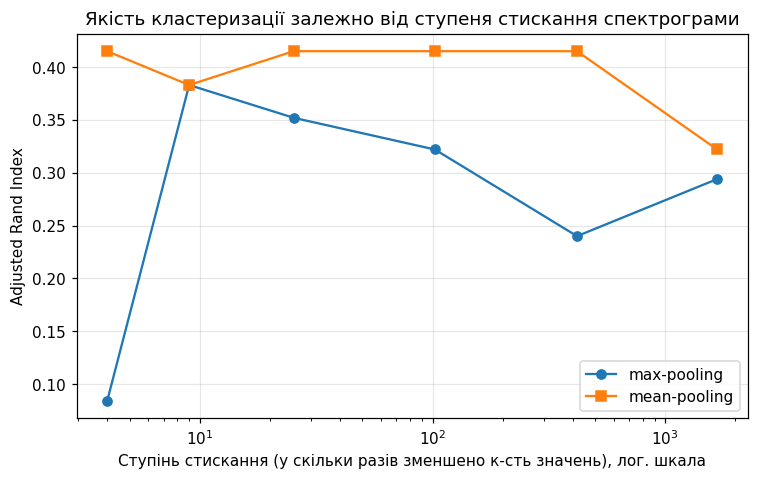

In [16]:
plt.figure(figsize=(7, 4.5))
for method, marker in [("max", "o"), ("mean", "s")]:
    sub = sweep_df[sweep_df.pooling == method]
    plt.plot(sub["compression_x"], sub["ARI"], marker=marker, label=f"{method}-pooling")
plt.xscale("log")
plt.xlabel("Ступінь стискання (у скільки разів зменшено к-сть значень), лог. шкала")
plt.ylabel("Adjusted Rand Index")
plt.title("Якість кластеризації залежно від ступеня стискання спектрограми")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Крок 4–5. Кластеризація `SpectralClustering` для обраної конфігурації

З графіка вище видно, що `mean`-pooling дає стабільно вищий і майже незмінний ARI ($\approx 0.42$) у широкому діапазоні стискання — від ядра `2×2` аж до `20×20` (тобто зменшення розміру спектрограми у понад 400 разів). Обираємо як компроміс між компактністю і швидкістю **`mean`-pooling з ядром `10×10`** (стискання приблизно у 100 разів, вектор ознак розміром 2156) і будуємо на цих даних фінальну кластеризацію.

In [17]:
from sklearn.metrics import confusion_matrix
import itertools

CHOSEN_METHOD = "mean"
CHOSEN_KSIZE = (10, 10)

X, y, names = [], [], []
for fn, (spec, label) in spectrograms.items():
    pooled = pooling_audio(spec, CHOSEN_KSIZE, method=CHOSEN_METHOD)
    X.append(pooled.flatten())
    y.append(label)
    names.append(fn)

X = np.array(X)
y = np.array(y)
names = np.array(names)
print(f"Обрана конфігурація: pooling={CHOSEN_METHOD}, kernel={CHOSEN_KSIZE}, X.shape={X.shape}")

clustering = SpectralClustering(n_clusters=2, affinity="nearest_neighbors", random_state=0)
cluster_labels = clustering.fit_predict(X)
ari = adjusted_rand_score(y, cluster_labels)
print(f"Adjusted Rand Index: {ari:.3f}")

# Мітки кластерів довільні (0/1) — вирівнюємо їх з реальними мітками для зручного аналізу
best_perm, best_acc = None, -1
for perm in itertools.permutations([0, 1]):
    mapped = np.array([perm[c] for c in cluster_labels])
    acc = (mapped == y).mean()
    if acc > best_acc:
        best_acc, best_perm = acc, perm

mapped_labels = np.array([best_perm[c] for c in cluster_labels])
print(f"Точність (accuracy) після вирівнювання міток кластерів: {best_acc:.3f}")

cm = confusion_matrix(y, mapped_labels)
cm_df = pd.DataFrame(cm, index=["true: dog", "true: chirping_birds"],
                      columns=["cluster: dog", "cluster: chirping_birds"])
print("\nМатриця плутанини (рядки — справжня категорія, стовпці — кластер):")
print(cm_df.to_string())

misclassified = names[mapped_labels != y]
print(f"\nКількість неправильно згрупованих файлів: {len(misclassified)} з {len(names)}")
for fn in misclassified:
    true_cat = category_map[fn]
    print(f"  {fn}: справжня категорія = {true_cat}")

Обрана конфігурація: pooling=mean, kernel=(10, 10), X.shape=(80, 2156)
Adjusted Rand Index: 0.415
Точність (accuracy) після вирівнювання міток кластерів: 0.825

Матриця плутанини (рядки — справжня категорія, стовпці — кластер):
                      cluster: dog  cluster: chirping_birds
true: dog                       33                        7
true: chirping_birds             7                       33

Кількість неправильно згрупованих файлів: 14 з 80
  2-117271-A-0.wav: справжня категорія = dog
  2-122616-A-14.wav: справжня категорія = chirping_birds
  2-72547-B-14.wav: справжня категорія = chirping_birds
  2-72547-D-14.wav: справжня категорія = chirping_birds
  3-136288-A-0.wav: справжня категорія = dog
  3-144028-A-0.wav: справжня категорія = dog
  3-180977-A-0.wav: справжня категорія = dog
  3-181132-A-14.wav: справжня категорія = chirping_birds
  4-182795-A-14.wav: справжня категорія = chirping_birds
  5-203128-B-0.wav: справжня категорія = dog
  5-208030-A-0.wav: справжня кате

### Крок 6. Аналіз кластерів

Щоб побачити структуру даних, спроєктуємо ознаки на 2 головні компоненти (PCA) і порівняємо справжні категорії зі знайденими кластерами.

Пояснена дисперсія перших 2 головних компонент: [0.557 0.092]


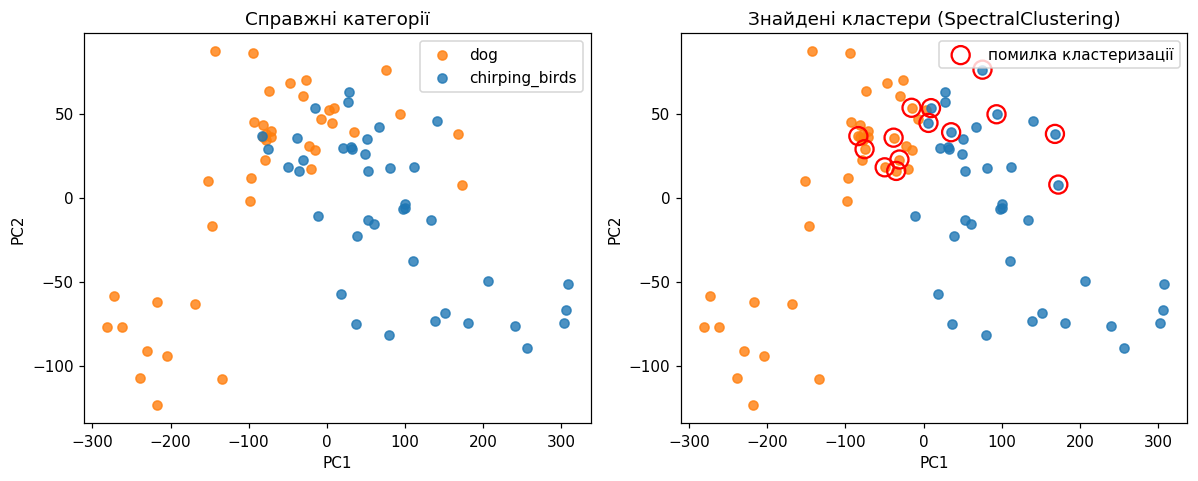

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)
print("Пояснена дисперсія перших 2 головних компонент:", np.round(pca.explained_variance_ratio_, 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for label, name_, color in [(0, "dog", "tab:orange"), (1, "chirping_birds", "tab:blue")]:
    mask = y == label
    axes[0].scatter(X2[mask, 0], X2[mask, 1], label=name_, color=color, alpha=0.8)
axes[0].set_title("Справжні категорії")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

for label, color in [(0, "tab:orange"), (1, "tab:blue")]:
    mask = mapped_labels == label
    axes[1].scatter(X2[mask, 0], X2[mask, 1], color=color, alpha=0.8)
# обводимо неправильно згруповані точки
mis_mask = mapped_labels != y
axes[1].scatter(X2[mis_mask, 0], X2[mis_mask, 1], facecolors="none",
                 edgecolors="red", s=140, linewidths=1.5, label="помилка кластеризації")
axes[1].set_title("Знайдені кластери (SpectralClustering)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend()

plt.tight_layout()
plt.show()

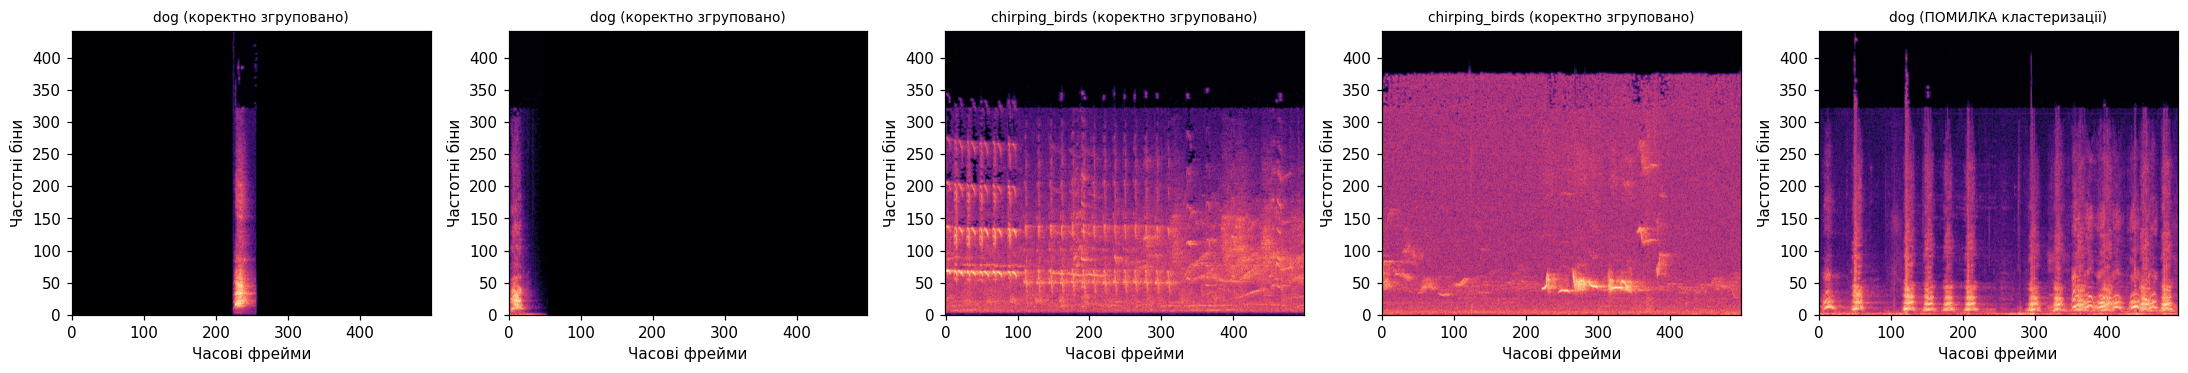

In [19]:
dog_files = [fn for fn in names if category_map[fn] == "dog"]
bird_files = [fn for fn in names if category_map[fn] == "chirping_birds"]

examples = [
    (dog_files[0], "dog (коректно згруповано)" if dog_files[0] not in misclassified else "dog (помилка)"),
    (dog_files[1], "dog (коректно згруповано)" if dog_files[1] not in misclassified else "dog (помилка)"),
    (bird_files[0], "chirping_birds (коректно згруповано)" if bird_files[0] not in misclassified else "chirping_birds (помилка)"),
    (bird_files[1], "chirping_birds (коректно згруповано)" if bird_files[1] not in misclassified else "chirping_birds (помилка)"),
]
if len(misclassified) > 0:
    examples.append((misclassified[0], f"{category_map[misclassified[0]]} (ПОМИЛКА кластеризації)"))

fig, axes = plt.subplots(1, len(examples), figsize=(4 * len(examples), 3.5))
for ax, (fn, title) in zip(axes, examples):
    spec, _ = spectrograms[fn]
    im = ax.imshow(spec, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Часові фрейми")
    ax.set_ylabel("Частотні біни")
plt.tight_layout()
plt.show()

### Крок 7. Висновки

**Чи потрапили звуки різного походження у різні кластери?** Здебільшого так. `SpectralClustering` без жодної інформації про справжні мітки розділив 80 звуків на дві групи, які узгоджуються зі справжніми категоріями `dog`/`chirping_birds` з Adjusted Rand Index $\approx 0.42$ і точністю (accuracy, після узгодження нумерації кластерів) $\approx 82.5\%$ — матриця плутанини майже симетрична: $33$ правильно з $40$ у кожній категорії, по $7$ переплутаних в обидва боки. Це значно краще за випадковий поділ (ARI $=0$), тобто частотний "відбиток" гавкоту собаки і щебетання птахів справді різний і вловлюється спектрограмою. На PCA-проєкції видно, що більшість помилок кластеризації зосереджені саме в перехідній зоні між двома "хмарами" точок — там, де частотно-часові характеристики запису випадково схожі на іншу категорію (наприклад, короткий різкий гавкіт з високочастотними обертонами може нагадувати щебетання, а безперервне цвірінькання на тлі шуму — розмите широкосмугове гавкання).

**Експерименти з різними ступенями стискання (pooling).** Ми порівняли `max`- і `mean`-pooling з ядрами від `2×2` до `40×40` (стискання від 4 до понад 1600 разів відносно вихідної спектрограми розміром $442\times499\approx 220\,558$ значень):

| pooling | kernel | розмір вектора | стискання, x | ARI |
|---|---|---|---|---|
| max | 2×2 | 55029 | 4× | 0.084 |
| max | 3×3 | 24402 | 9× | 0.383 |
| max | 5×5 | 8712 | 25× | 0.352 |
| max | 10×10 | 2156 | 102× | 0.322 |
| max | 20×20 | 528 | 418× | 0.240 |
| max | 40×40 | 132 | 1671× | 0.294 |
| **mean** | 2×2 | 55029 | 4× | **0.415** |
| **mean** | 3×3 | 24402 | 9× | 0.383 |
| **mean** | 5×5 | 8712 | 25× | **0.415** |
| **mean** | 10×10 | 2156 | 102× | **0.415** |
| **mean** | 20×20 | 528 | 418× | **0.415** |
| mean | 40×40 | 132 | 1671× | 0.322 |

`mean`-pooling виявився і кращим, і значно стабільнішим за `max`-pooling: якість кластеризації (ARI $\approx 0.42$) практично не змінюється, поки стискання не перевищує ~400 разів, і лише при екстремальному стисканні (40×40, у 1671 раз) починає помітно падати. `max`-pooling натомість чутливіший до розміру ядра й у середньому дає гірший результат — імовірно тому, що бере лише найгучніше значення в кожному вікні і "викидає" загальний енергетичний профіль сигналу, який якраз і несе інформацію про категорію звуку, тоді як усереднення краще зберігає цей профіль навіть при сильному стисканні.

**Висновок про значення застосування перетворення Фур'є для вилучення ознак.** Сирий звуковий сигнал — це 220 500 відліків амплітуди в часі, які самі по собі майже не мають сенсу для порівняння двох записів (два гавкоти в різний момент часу чи з різною гучністю дадуть зовсім різні відліки, хоча "звучать" схоже). Перетворення Фур'є (тут — короткочасне, у вигляді спектрограми) переводить сигнал у частотно-часову область, де кожен клас звуків має характерний і відносно стійкий "відбиток" (для гавкоту собаки — короткі широкосмугові імпульси з енергією в нижніх і середніх частотах; для щебетання птахів — вужчі, високочастотні смуги, що змінюються по частоті з часом). Саме ця властивість дозволила чисто неконтрольованому методу кластеризації відокремити категорії без жодних міток. Додатково pooling показав, що майже вся ця розрізняльна інформація зосереджена у грубій, низькороздільній структурі спектрограми: стиснувши вектор ознак у сотні разів (з 220 558 до ~500–2000 значень), ми практично не втрачаємо якість кластеризації. Це і є практична цінність FFT-based ознак: вони перетворюють великий, "сирий" і малоінформативний в оригінальному вигляді сигнал на компактний, обчислювально дешевий і водночас змістовний вектор ознак, придатний для подальшої кластеризації чи класифікації.